## **Evaluation Metrics And Regression Implementation**

### ***Theory***

1. What does R-squared represent in a regression model?

--> R-squared represents the percentage variation in y explained by x.


2. What are the assumptions of linear regression?

--> There are four assumption of linear regression:

1. Linearity: x and y should have linear relation

2. Homoscedacity : The Variance of the error should be constant

3. Independent : There should be independent rows 

4. Multicollinearity :- There should be no multi-correlated feature in our data

5. Normality in error: There should be normalized error in distribution

3. What is the difference between R-squared and Adjusted R-squared?

--> R-squared means the percentage variation in y explained by x. 

Adjusted R² penalizes adding unnecessary predictors and increases only when the new variable improves the model meaningfully


4. Why do we use Mean Squared Error (MSE)?

--> We use MSE because:

It measures average squared prediction error

Squaring penalizes large errors more strongly

It is mathematically convenient (differentiable), making optimization easier

5. What does an Adjusted R-squared value of 0.85 indicate?

--> It means about 85% of the variance in Y is explained by the model after adjusting for the number of predictors.

This typically indicates a strong model fit, assuming assumptions are reasonably satisfied.

6. How do we check for normality of residuals in linear regression?

--> Common methods:

Histogram of residuals

Q-Q plot (best visual check)

Statistical tests:

Shapiro-Wilk test

Kolmogorov–Smirnov test

Anderson-Darling test

7. What is multicollinearity, and how does it impact regression?

--> Multicollinearity happens when independent variables are highly correlated with each other.

Impact:

Coefficients become unstable

Standard errors increase → p-values become unreliable

Difficult to interpret the effect of individual predictors

8. What is Mean Absolute Error (MAE)?

--> MAE is the average of absolute differences between actual and predicted values:

𝑀𝐴𝐸 = 1/𝑛 ∑ ∣𝑦𝑖−𝑦^𝑖∣

It is:

Easier to interpret

Less sensitive to outliers than MSE

9. What are the benefits of using an ML pipeline?

--> Benefits:

Prevents data leakage

Ensures consistent preprocessing during training and testing

Easier deployment (single workflow)

Supports reproducibility

Works smoothly with cross-validation and hyperparameter tuning

10. Why is RMSE considered more interpretable than MSE?

--> Because RMSE is in the same unit as the target variable (Y), while MSE is in squared units.

11. What is pickling in Python, and how is it useful in ML?

--> Pickling is saving a Python object into a binary format using pickle.

In ML, it helps to:

Save trained models

Save preprocessing objects (scalers, encoders)

Reload models later without retraining

12. What does a high R-squared value mean?

--> A high R² means the model explains a large portion of the variance in Y.

However:

It does not guarantee good predictions

It does not confirm causality

It can be inflated by overfitting

13. What happens if linear regression assumptions are violated?

--> Violations can cause:

Biased or inefficient estimates

Wrong confidence intervals and p-values

Poor generalization and unstable predictions

Misleading conclusions

14. How can we address multicollinearity in regression?

--> Solutions:

Remove highly correlated features

Use VIF (Variance Inflation Factor) to detect and reduce

Combine variables (feature engineering / PCA)

Use regularization:

Ridge regression (L2) is best for multicollinearity

Lasso (L1) also helps by feature selection

15. How can feature selection improve model performance in regression analysis?

--> Feature selection helps by:

Reducing overfitting

Improving interpretability

Lowering training time

Reducing noise and multicollinearity

Improving generalization

16. How is Adjusted R-squared calculated?

--> Adjusted R2= 1−(1−R2)(n−1)/ (n−p−1)

Where:

𝑛 = number of observations

𝑝 = number of predictors

17. Why is MSE sensitive to outliers?

--> Because errors are squared, large errors become extremely large.

18. What is the role of homoscedasticity in linear regression?

--> Homoscedasticity means residuals have constant variance across all levels of predicted values.

Why important:

Ensures unbiased estimation of standard errors

Makes hypothesis tests and confidence intervals reliable

19. What is Root Mean Squared Error (RMSE)?

--> RMSE= 1/n (∑(yi−y^i)^2)^1/2	​


It represents the typical prediction error magnitude in the same unit as Y.

20. Why is pickling considered risky? 

--> Pickle can execute arbitrary code during loading, so:

Loading untrusted pickle files can lead to security vulnerabilities

It is unsafe for files from unknown sources

21. What alternatives exist to pickling for saving ML models? 

--> Safer and commonly used alternatives:

joblib (better for large NumPy arrays)

ONNX (cross-platform, production friendly)

PMML (model interchange format)

TensorFlow SavedModel / Keras .h5 (deep learning)

Export model parameters to JSON (custom models)

22. What is heteroscedasticity, and why is it a problem?

--> Heteroscedasticity means residual variance is not constant.

Problems:

Standard errors become wrong

Confidence intervals and p-values become unreliable

Model may perform unevenly across ranges of Y

23. How can interaction terms enhance a regression model's predictive power?

--> Interaction terms allow the model to capture situations where:

The effect of one feature depends on another feature

Example:

Salary effect depends on experience

Price effect depends on season

This increases model flexibility and can improve prediction accuracy when such relationships exist.

### ***Practical***

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

1. Write a Python script to visualize the distribution of errors (residuals) for a multiple linear regression modia using Seaborn's "diamonds" dataset.



In [2]:
df1 = sns.load_dataset("diamonds")
df1

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df1.describe

<bound method NDFrame.describe of        carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]>

In [4]:
df1.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [5]:
x = df1[['carat','depth','table']]
y = df1[['price']]

In [6]:
x.shape, y.shape

((53940, 3), (53940, 1))

In [7]:
x_train , x_test , y_train, y_test  = train_test_split(x,y, test_size=0.25,random_state=42)

In [8]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((40455, 3), (40455, 1), (13485, 3), (13485, 1))

In [9]:
lr = LinearRegression()
lr

LinearRegression()

In [10]:
model = lr.fit(x_train,y_train)
model

LinearRegression()

In [11]:
y_pred = model.predict(x_test)
y_pred

array([[-353.48180392],
       [2530.42100689],
       [1011.75303964],
       ...,
       [7447.83517057],
       [5373.750409  ],
       [5520.15048754]])

In [12]:
error = y_test - y_pred
error

,price
1388,912.481804
50052,-329.421007
41645,226.246960
42377,73.737907
17244,-3131.707181
...,...
36825,-1159.189888
24803,2256.864611
20999,1767.164829
8471,-957.750409


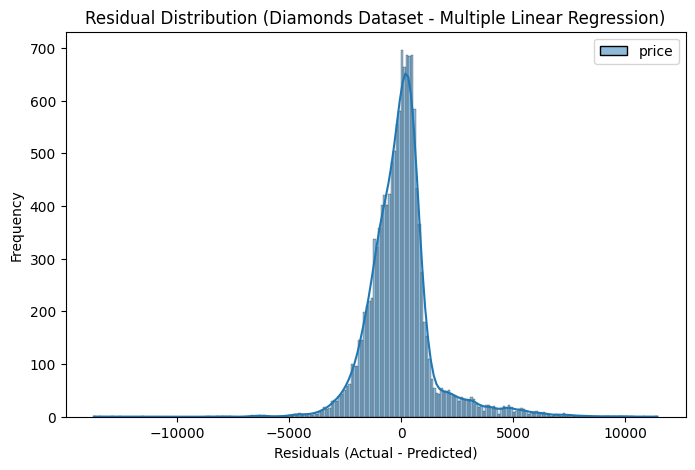

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(error, kde=True)
plt.title("Residual Distribution (Diamonds Dataset - Multiple Linear Regression)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

2. Write a Python script to calculate and print Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) for a linear regression model.



In [14]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 2310119.6354749314


In [15]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE :", mae)

MAE : 991.8625215831562


In [16]:
rmse = np.sqrt(mse)
print("RMSE", rmse)

RMSE 1519.9077720292541


3. Write a Python script to check if the assumptions of linear regression are met. Use a scatter plot to check linearity, residuals plot for homoscedasticity, and correlation matrix for multicollinearity.



In [17]:
df2 = sns.load_dataset("tips")

In [18]:
# Multiple regression features
X = df2[["total_bill", "size"]]
y = df2["tip"]



In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)



In [20]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred



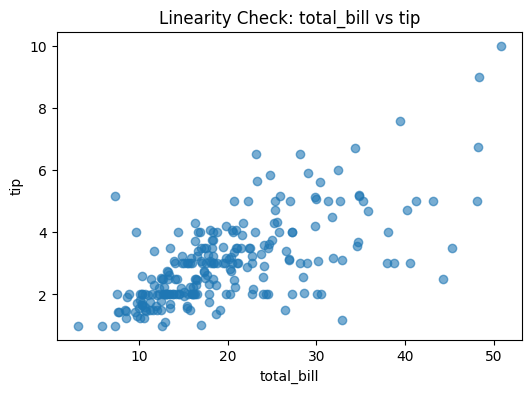

In [21]:
# 1) Linearity check (scatter plot)
plt.figure(figsize=(6, 4))
plt.scatter(df2["total_bill"], df2["tip"], alpha=0.6)
plt.title("Linearity Check: total_bill vs tip")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.show()



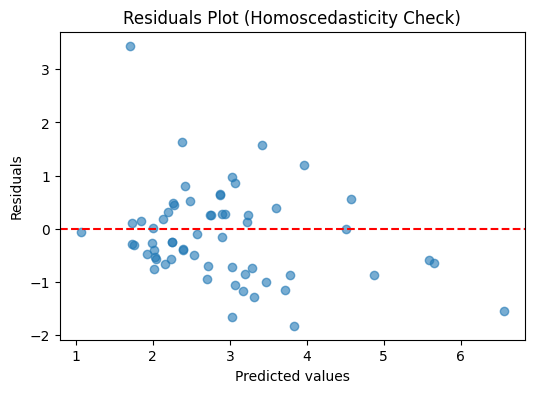

In [22]:
# 2) Homoscedasticity check (residual plot)
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Plot (Homoscedasticity Check)")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()



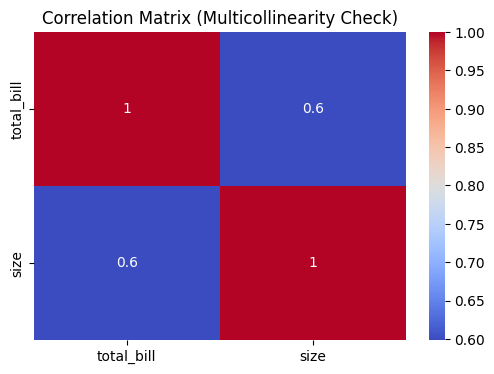

In [23]:
# 3) Multicollinearity check (correlation matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Multicollinearity Check)")
plt.show()

4. Write a Python script that creates a machine learning pipeline with feature scaling and evaluates the performance of different regression models





In [24]:

from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor


df = sns.load_dataset("diamonds")

# Basic preprocessing: encode categorical using get_dummies
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}

for name, reg in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("model", reg)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} R2 Score: {r2_score(y_test, y_pred):.4f}")


LinearRegression R2 Score: 0.9189
Ridge R2 Score: 0.9189
Lasso R2 Score: 0.9189
DecisionTree R2 Score: 0.9649


5. Implement a simple linear regression model on a dataset and print the model's coefficients, intercept, and R-squared score.

In [25]:
x = df2[['total_bill']]
y = df2[["tip"]]

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)


In [27]:
model= lr.fit(x_train,y_train)

In [28]:
y_pred = model.predict(x_test)

In [29]:
print(model.coef_)

[[0.10941451]]


In [30]:
print(model.intercept_)

[0.86159838]


In [31]:
r2 = r2_score(y_test,y_pred)
print("r2_score", r2)

r2_score 0.44013502111404923


6. Write a Python script that analyzes the relationship between total bill and tip in the 'tips' dataset using simple linear regression and visualizes the results.



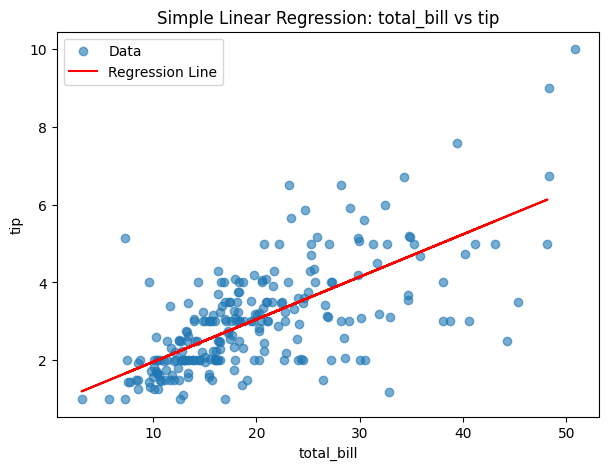

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x_test, y_pred, color="red", label="Regression Line")
plt.title("Simple Linear Regression: total_bill vs tip")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.legend()
plt.show()


7. Write a Python script that fits a linear regression model to a synthetic dataset with one feature. Use the model to predict new values and plot the data points along with the regression line.



Predictions for X_new: [5.60015285 8.37026624]


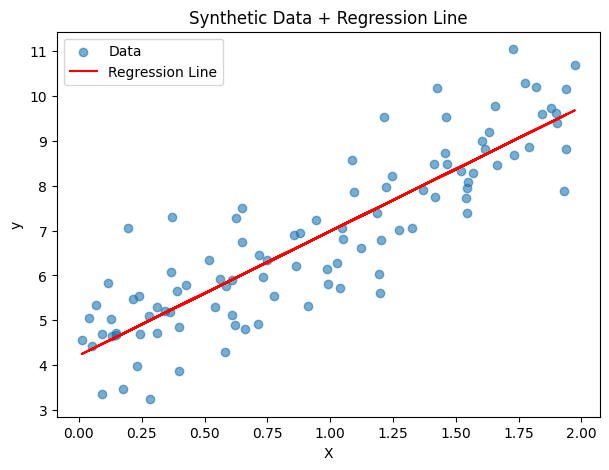

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(100)

model = LinearRegression()
model.fit(X, y)

# Predict new values
X_new = np.array([[0.5], [1.5]])
y_new_pred = model.predict(X_new)

print("Predictions for X_new:", y_new_pred)

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data + Regression Line")
plt.legend()
plt.show()


8. Write a Python script that pickles a trained linear regression model and saves it to a file.



In [34]:
import pickle
with open("linear_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved as linear_model.pkl")

Model saved as linear_model.pkl


9. Write a Python script that fits a polynomial regression model (degree 2) to a dataset and plots the regression curve.


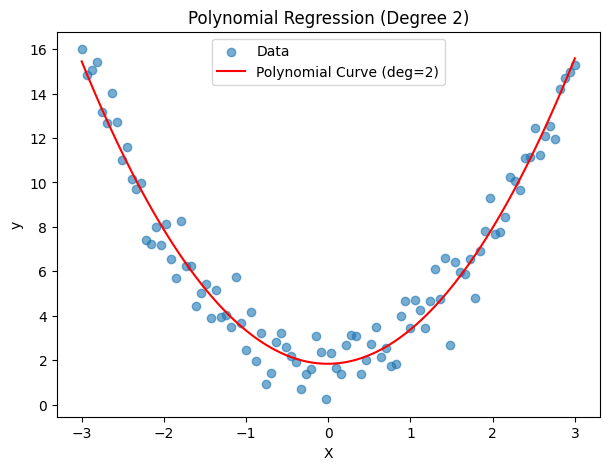

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(42)

X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 2 + 1.5 * X[:, 0]**2 + np.random.randn(100)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred, color="red", label="Polynomial Curve (deg=2)")
plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()



10. Generate synthetic data for simple linear regression (use random values for X and y) and fit a linear regression model to the data. Print the model's coefficient and intercept.


In [36]:
np.random.seed(42)


In [37]:
x = np.random.rand(100, 1) * 10
y = 5 + 2.5 * X[:, 0] + np.random.randn(100) * 21

In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [39]:
lr  = lr.fit(x_train,y_train)
lr

LinearRegression()

In [40]:
lr.predict(x_test)

array([ 8.37946431, -2.09601626, -0.55125584,  0.83144429,  5.91932156,
        3.63370255,  5.4988669 , -1.6962379 ,  8.92101198,  4.46053617,
        3.73713146,  1.52425856, -1.09586327, -2.77724638,  7.6733115 ,
        7.21429879, -0.53897637,  8.2473181 , -1.30985701,  7.03150368,
       -2.43685552, -2.00005854,  6.6641657 ,  8.74705648, -3.25613218])

In [41]:
lr.coef_

array([-1.26017938])

In [42]:
lr.intercept_

9.180413535256092


11. Write a Python script that fits polynomial regression models of different degrees to a synthetic dataset and compares their performance


In [43]:
np.random.seed(42)

X = np.linspace(-3, 3, 200).reshape(-1, 1)
y = 2 + 0.5 * X[:, 0]**3 - X[:, 0]**2 + np.random.randn(200)

for degree in [1, 2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    print(f"Degree {degree} R2 Score: {r2_score(y, y_pred):.4f}")


Degree 1 R2 Score: 0.6535
Degree 2 R2 Score: 0.8639
Degree 3 R2 Score: 0.9760
Degree 4 R2 Score: 0.9760
Degree 5 R2 Score: 0.9767



12. Write a Python script that fits a simple linear regression model with two features and prints the model's coefficients, intercept, and R-squared score.


In [44]:
x = df2[['total_bill','size']]
y = df2[['tip']]

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [46]:
model = lr.fit(x_train,y_train)

In [47]:
model.coef_

array([[0.09495423, 0.24183759]])

In [48]:
model.intercept_

array([0.53228396])


13. Write a Python script that generates synthetic data, fits a linear regression model, and visualizes the regression line along with the data points.


In [49]:
np.random.seed(42)

In [50]:
X = np.random.rand(80, 1) * 5
y = 3 + 4 * X[:, 0] + np.random.randn(80)



In [51]:
model = LinearRegression()
model.fit(X, y)



LinearRegression()

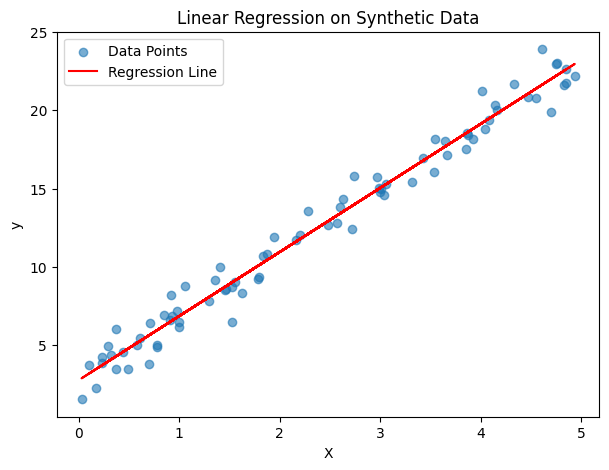

In [52]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6, label="Data Points")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.title("Linear Regression on Synthetic Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


14. Write a Python script that uses the Variance Inflation Factor (VIF) to check for multicollinearity in a dataset with multiple features.


In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [54]:
df1

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [55]:
df1 = df1[['carat','depth','table','x','y','z']].dropna()

In [56]:
vif = pd.DataFrame()
vif['Features'] = df1.columns
vif['VIF'] = [variance_inflation_factor(df1.values, i) for i in range(df1.shape[1])]
print(vif)

  Features          VIF
0    carat    70.132799
1    depth   515.146274
2    table   500.595341
3        x  1284.949828
4        y   530.998218
5        z   540.677349



15. Write a Python script that generates synthetic data for a polynomial relationship (degree 4), fits a polynomial regression model, and plots the regression curve.


In [57]:
np.random.seed(42)

X = np.linspace(-2, 2, 200).reshape(-1, 1)
y = 1 + 2*X[:, 0] - 3*(X[:, 0]**2) + 0.5*(X[:, 0]**4) + np.random.randn(200)

In [58]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

In [59]:
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

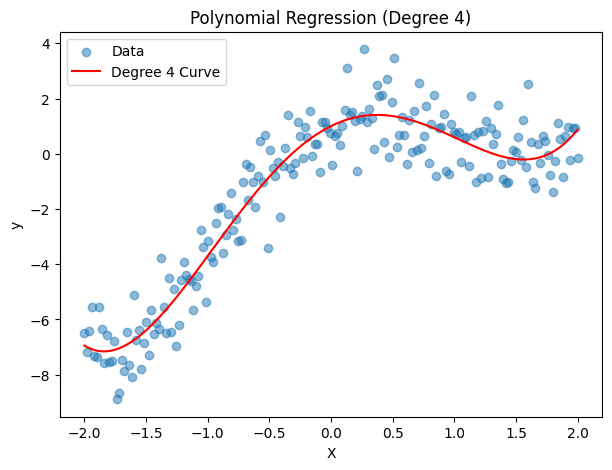

In [60]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.5, label="Data")
plt.plot(X, y_pred, color="red", label="Degree 4 Curve")
plt.title("Polynomial Regression (Degree 4)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


16. Write a Python script that creates a machine learning pipeline with data standardization and a multiple linear regression model, and prints the R-squared score.


In [61]:
x = df2[["total_bill", "size"]]
y = df2["tip"]



In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(x_train, y_train)

print("R-squared Score:", pipe.score(x_test, y_test))

R-squared Score: 0.4811084097989492



17. Write a Python script that performs polynomial regression (degree 3) on a synthetic dataset and plots the regression curve.


In [63]:
X = np.linspace(-3, 3, 150).reshape(-1, 1)
y = 2 + 0.8 * X[:, 0]**3 - 1.2 * X[:, 0] + np.random.randn(150)

In [64]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

In [65]:
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

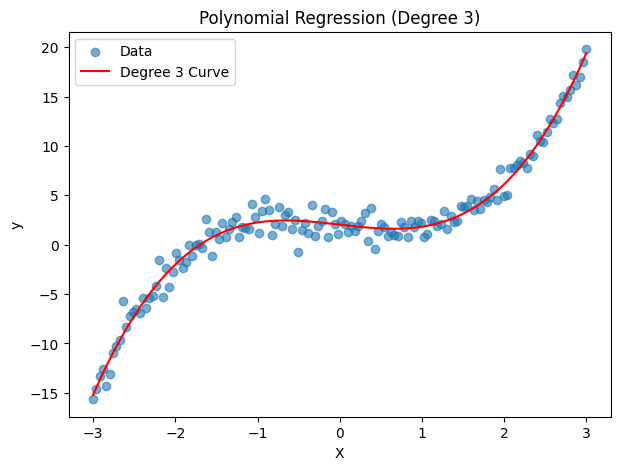

In [66]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred, color="red", label="Degree 3 Curve")
plt.title("Polynomial Regression (Degree 3)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


18. Write a Python script that performs multiple linear regression on a synthetic dataset with 5 features. Print the R-squared score and model coefficients


In [67]:
X = np.random.rand(300, 5)
true_coef = np.array([2.0, -1.5, 3.2, 0.7, -2.1])
y = X @ true_coef + np.random.randn(300) * 0.5

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [69]:
print("R-squared Score:", model.score(X_test, y_test))
print("Coefficients   :", model.coef_)
print("Intercept      :", model.intercept_)

R-squared Score: 0.8678646172025373
Coefficients   : [ 1.96977403 -1.58319279  3.19248819  0.72582359 -2.08057852]
Intercept      : 0.08470470547255404



18. Write a Python script that generates synthetic data for linear regression, fits a model and visualizes the data points along with the regression line.


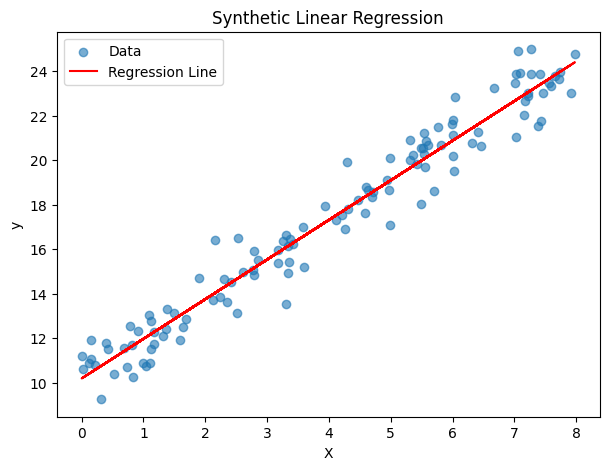

In [70]:
np.random.seed(1)

X = np.random.rand(120, 1) * 8
y = 10 + 1.8 * X[:, 0] + np.random.randn(120)

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.title("Synthetic Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


20. Create a synthetic dataset with 3 features and perform multiple linear regression. Print the model's R-squared score and coefficients.


In [71]:
np.random.seed(42)

X = np.random.rand(200, 3)
coef = np.array([4.0, -2.0, 1.5])
y = X @ coef + np.random.randn(200) * 0.3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("R-squared Score:", model.score(X_test, y_test))
print("Coefficients   :", model.coef_)
print("Intercept      :", model.intercept_)

R-squared Score: 0.9698184170051963
Coefficients   : [ 3.99322019 -2.11077379  1.43587355]
Intercept      : 0.07358323226592334



21. Write a Python script that demonstrates how to serialize and deserialize machine learning models using joblib instead of pickling.


In [73]:
import joblib

In [74]:
X = df2[["total_bill"]]
y = df2["tip"]

model = LinearRegression()
model.fit(X, y)

# Save model
joblib.dump(model, "linear_model_joblib.pkl")
print("Saved using joblib!")

# Load model
loaded_model = joblib.load("linear_model_joblib.pkl")
print("Loaded model coefficient:", loaded_model.coef_[0])

Saved using joblib!
Loaded model coefficient: 0.10502451738435337



22. Write a Python script to perform linear regression with categorical features using one-hot encoding. Use the Seaborn 'tips' dataset.


In [75]:
df_encoded = pd.get_dummies(df2, drop_first=True)

X = df_encoded.drop("tip", axis=1)
y = df_encoded["tip"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("R-squared Score:", model.score(X_test, y_test))

R-squared Score: 0.43730181943482516



23. Compare Ridge Regression with Linear Regression on a synthetic dataset and print the coefficients and R-squared score.


In [76]:
np.random.seed(42)

X = np.random.rand(300, 5)
coef = np.array([5, -3, 2, 0.5, -1])
y = X @ coef + np.random.randn(300) * 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression()
lin.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Linear Regression:")
print("R2:", lin.score(X_test, y_test))
print("Coefficients:", lin.coef_)

print("\nRidge Regression:")
print("R2:", ridge.score(X_test, y_test))
print("Coefficients:", ridge.coef_)

Linear Regression:
R2: 0.25357844261642004
Coefficients: [ 4.4554186  -3.20830785  1.8289695   1.44665225  0.40010845]

Ridge Regression:
R2: 0.2605562412635085
Coefficients: [ 4.27781136 -3.06907246  1.73678732  1.38120982  0.40127835]



24. Write a Python script that uses cross-validation to evaluate a Linear Regression model on a synthetic dataset


In [78]:
from sklearn.model_selection import cross_val_score

In [79]:
np.random.seed(42)

X = np.random.rand(200, 3)
y = 3*X[:, 0] - 2*X[:, 1] + 1.5*X[:, 2] + np.random.randn(200) * 0.2

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross-validation R2 scores:", scores)
print("Mean R2:", scores.mean())

Cross-validation R2 scores: [0.95201219 0.97065242 0.97137091 0.9768836  0.95553816]
Mean R2: 0.9652914573983253



25. Write a Python script that compares polynomial regression models of different degrees and prints the R-squared score for each.

In [80]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

X = np.linspace(-3, 3, 250).reshape(-1, 1)
y = 1 + 2*X[:, 0] - 0.5*(X[:, 0]**2) + 0.2*(X[:, 0]**3) + np.random.randn(250)

for degree in [1, 2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    print(f"Degree {degree} R2 Score: {r2_score(y, y_pred):.4f}")


Degree 1 R2 Score: 0.8972
Degree 2 R2 Score: 0.9544
Degree 3 R2 Score: 0.9723
Degree 4 R2 Score: 0.9724
Degree 5 R2 Score: 0.9725
